# ==========================================

# Job Title Normalisation

This notebook builds the full job title normalisation pipeline used in Chapter 0 of the Job Intelligence Engine. Raw job titles are extremely noisy, inconsistent across companies, and full of formatting artefacts, seniority signals, and irrelevant tokens. To use titles in any meaningful modelling downstream—salary prediction, skill demand modelling, competitiveness scoring, or recommendations—we first need a clean, standardised representation of each role.

The workflow in this notebook proceeds in three stages:

1. **Initial Cleaning and Normalisation**  
   We standardise basic formatting (casing, spacing, punctuation) and remove obvious noise while preserving the domain-specific terms that matter for semantics. This eliminates superficial variation and reduces the number of distinct titles.

2. **Seniority Extraction and Decomposition**  
   We identify both keyword- and Roman-numeral-based seniority markers, extract them into a dedicated column, and remove them from the base title. This prevents titles like “Senior Data Scientist” and “Data Scientist II” from becoming separate clusters later on.

3. **Semantic Structuring with SBERT + Clustering**  
   We transform each cleaned base title into a semantic embedding using SBERT and cluster these embeddings into coherent job families. This step captures the *meaning* of the roles rather than their surface wording. The output is a stable, interpretable high-level job title or job family that can be used consistently throughout the rest of the project.

By the end of this notebook, each job in the dataset has:
- a normalised base title,
- a separate seniority level,
- and a high-level job family derived from semantic clustering.

This completes the job title component of Chapter 0 and prepares the dataset for skill extraction and all downstream modelling.

# ==========================================

#

## Set-Up

In [1]:
import sys
print(sys.executable)

/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/bin/python


In [2]:
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [3]:
from src.job_intel.config import INTERIM_CLEANED_JOBS

## Import libraries

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter

## Import data

In [5]:
df = pd.read_csv(INTERIM_CLEANED_JOBS)

## --------------------------------------------


# Top layer titles normalisation

The goal of this section was to take the raw job titles and remove superficial variation that creates artificial uniqueness. Many titles differed only by casing, punctuation, or spacing, and these inconsistencies needed to be eliminated before deeper semantic work.

### Objectives
- Standardise surface-level formatting across all titles.
- Remove trivial noise that does not affect meaning.
- Preserve meaningful domain content for downstream clustering.
- Lay the groundwork for later steps (seniority extraction and semantic cleaning).

### Steps Completed
1. **Lowercasing & Whitespace Normalisation**
   - Converted all titles to lowercase.
   - Stripped leading/trailing whitespace.
   - Collapsed repeated spaces and standardised separators.

2. **Basic Punctuation Removal**
   - Replaced or removed common punctuation (hyphens, slashes, commas, pipes, etc.).
   - Ensured format inconsistencies did not inflate the number of unique titles.

3. **Initial Noise Filtering**
   - Identified and removed obvious non-informative tokens (e.g., stray symbols, formatting leftovers).
   - Ensured that tokens like location fragments or company artefacts did not appear in the cleaned titles.

4. **Preservation of Domain Information**
   - Maintained key technical and functional tokens (e.g., *data*, *cloud*, *analytics*, *software*).
   - Avoided over-cleaning that would collapse genuinely distinct job roles.

### Outcome
After this first pass, the titles were significantly cleaner and more consistent.  
This initial normalisation dramatically reduced superficial variation and prepared the dataset for the deeper semantic cleaning and seniority extraction that followed later in the day.

This step forms the base of the `job_title_base` transformation pipeline and ensures that all downstream SBERT embeddings operate on clean, standardised text.


## --------------------------------------------

In [6]:
df['job_title_raw'] = df['Job Title'].astype(str).str.strip()
print("Number of rows:", len(df))
print("Unique raw titles:", df['job_title_raw'].nunique())
print("\nSample titles:")
print(df['job_title_raw'].sample(20, random_state=42).to_list())

Number of rows: 6162
Unique raw titles: 3014

Sample titles:
['Data Scientist- Machine Learning Software Engineer', 'Data Analyst', 'Data Analyst', 'Consultant, Telematics Data Engineer', 'Data & Analytics Consultant |', 'Systems/Data Analyst', 'Data Analyst', 'Data Analyst', 'Systems Analyst, Quality Data System', 'Big Data Engineer/Admin', 'Data Analyst Junior', 'Senior Data Scientist, Ad Platforms', 'Senior Marketing Data Analyst', 'Senior Data Analyst', 'Data Management Analyst (ADDM04) SEC SVCS OPS DATA GOVERNANCE - NA', 'Senior Data Scientist with Extensive Industrial Experience', 'Content Data Scientist, Apple Media Products Data Science', 'Field Applications Scientist, CA', 'Data Analyst', 'Principal Data Scientist, Machine Learning']


3014 unique titles are a lot!!!

### Identify noise and decorators within the job titles
I extracted and explored the bag of word and using generative AI identified irrelevant words for determining job family and domain. I still labelled them carefully for potential future use. For example, skill or location extraction.

In [7]:
noise_terms = [

    # -------------------------------------------------
    # Contract / job-advert / recruiting meta
    # -------------------------------------------------
    "contract", "temporary", "temp",
    "full time", "part time", "fulltime", "full",
    "freelance", "seasonal",
    "hire", "hiring",
    "opportunity", "opportunities",
    "urgent", "immediate", "immediate start", "asap",
    "apply now", "now hiring",
    "opening", "openings", "job opening",
    "position", "positions", "post", "posting",
    "reposted", "itjobs",
    "jobs", "job", "careers", "candidate",

    # -------------------------------------------------
    # Work mode / location-independent pattern
    # -------------------------------------------------
    "remote", "hybrid", "onsite", "on-site",
    "wfh", "work from home", "telecommute",

    # -------------------------------------------------
    # Time / schedule / seniority-like ordinals
    # (we handle roman numerals separately)
    # -------------------------------------------------
    "month", "months", "year", "years",
    "day", "days", "week", "weeks", "hours",
    "shift", "roster", "tuesday", "saturday",
    "weekend", "weekends", "weekly",
    "evenings", "evening", "nights", "night",
    "2nd", "3rd", "1st", "pm", "am", "00pm", "30pm",
    "yr", "yrs", "late", "stage",

    # -------------------------------------------------
    # Eligibility / HR boilerplate / generic HR meta
    # -------------------------------------------------
    "relocation", "eligibility",
    "visa", "sponsorship",
    "anywhere", "compensation",
    "resident", "candidates",
    "required", "must",
    "incentives", "proficiency",
    "identity", "enrollment",
    "permanent",

    # -------------------------------------------------
    # Generic stopwords (safe to strip from titles)
    # -------------------------------------------------
    "and", "or", "with", "in", "of", "for",
    "to", "the", "at", "only", "on", "is",
    "up", "may", "as", "all", "two",
    "my", "re", "from", "into", "over", 

    # -------------------------------------------------
    # Junk / corrupted tokens
    # -------------------------------------------------
    "s", "w", "t", "f", "bm", "ts", "â", "area4",
    "_", "_long", "d", "‰øùÂÆû‰π†‰øùÂ∞±‰∏ö",
    "x", "ch", "ihha", "ctj", "hsv", "mbse", "dw", "edw",
    "lrec", "idq", "c3", "e3", "1q",

    # -------------------------------------------------
    # Pure location tokens (we have a location column)
    # -------------------------------------------------
    # US states
    "ny", "nj", "ct", "fl", "oh", "pa", "tx", "mn", "wi",
    "nc", "sc", "al", "tn", "ky", "va", "wv", "md", "de",
    # Cities, regions, countries, generic geo
    "dallas", "chicago", "austin", "atlanta",
    "toronto", "washington", "antonio",
    "moines", "louis", "columbus", "nationwide",
    "ca", "san", "us", "la", "phoenix",
    "diego", "houston", "irving", "philadelphia",
    "francisco", "jolla", "south",
    "jacksonville", "atx", "local",
    "jersey", "jose", "ga", "california", "los",
    "angeles", "usa", "square", "sfo",
    "oklahoma", "bay", "nyc", "sf", "charlotte",
    "america", "york", "dc", "chandler",
    "canada", "tempe", "fargo", "wells",
    "east", "lake", "sinai", "harborside",
    "international", "mount", "missouri",
    "stafford", "sugar", "land", "arizona",
    "americas", "glendale", "scottsdale",
    "mesa", "gilbert", "burbank", "culver",
    "europe", "aurora", "arlington", "plano",
    "grand", "prairie", "wilmington", "lawson",
    "uk", "greenwood", "ohio",
    "india", "texas",
    # Extra locations / geo-ish
    "seattle", "denver", "norfolk", "whittier",
    "woodridge", "cerritos", "glenview",
    "bellaire", "hills", "hickory",
    "beach", "village", "acorn", "centennial",
    "midwest", "west", "ocean",

    # -------------------------------------------------
    # Languages / language requirements (not role type)
    # -------------------------------------------------
    "english", "korean", "german", "language",
    "chinese", "spanish", "bilingual",
    "japanese", "indonesian", "fluent", "speaking",
    
    # -------------------------------------------------
    # Companies / organisations / brand names
    # (not role semantics)
    # -------------------------------------------------
    "disney", "hbo", "star", "max",
    "apple", "ibm", "salesforce", "oracle",
    "fleishmanhillard", "veritystream",
    "epic", "tibco", "abbott", "dell",
    "gao", "cowen", "pfk", "usdc",
    "provost", "quantumblack", "fbi",
    "google", "outsights", "lacera",
    "kaiser", "tyson", "bernard",
    "ais", "avmed", "hutchinson",
    "teleflora", "facilitysource",
    "publicis", "wirecutter",
    "peacock", "anderson", "kapil",
    "bhalla", "cedars", "svendsen",
    "novi", "gtech", "point72",
    "acurian", "ppd", "horsham",
    "schaeffer", "atlantic", "microsoft",
    "hctra", "gnhcc", "qsight", "sdsa", 
    "docutech", "qliksense",
    "woocommerce", "applecare",
    "amazon", "trello", "sdma",
    "upstart", "tealium", "lilly",
    "cognizant", "jll", "deloitte", 
    "cooper", "spotify", "mongo", 

    # -------------------------------------------------
    # SKILLS / STACK TERMS REMOVED FROM TITLE
    # (we keep this section so we can reuse the list
    #  for skill extraction later, but they are stripped
    #  from the job title text used for embeddings)
    # -------------------------------------------------
    # Cloud / data platforms
    "azure", "sap", "teradata", "workday", "salesforce",
    "splunk", "hana", "collibra", "mongodb", "oracle",
    "hive", "snowflake", "databricks", "powerbi",
    "kafka", "kubernetes", "docker", "talend",
    "geospatial", "arcgis", "erp", "lims", "cloudera",
    "greenplum", "memsql", "celonis", "websphere",
    "sharepoint", "infosphere", "hpc",

    # Programming languages / frameworks
    "python", "java", "r", "sas", "nlp",
    "plsql", "sql", "xml", "csv", "js",

    # Data / ML / devops
    "etl", "cloud", "hadoop", "spark",
    "crm", "mdm", "aws", "devops", "cloudops",
    "pyspark", "datamodeling",

    # Misc tools / tech-y but not core role type
    "guidewire", "hub", "ecommerce", "datastage", "stack",
    "informatica", "pcr", "hplc", "gpu", "polygraph",
    "nifi", "elasticsearch", "logstash",
    "portal", "sdk", "cli", "scala",
    "ecomm", "systemc", "oci", "ci", "cd",
    "datalakes", "kibana", "tableau", "toad",
    "qliksense", "spotfire", "jupyter", "notebook",
    "server", "app", "apps", "node", "cpu", "graphics",

    # -------------------------------------------------
    # Tasks / processes / generic actions
    # -------------------------------------------------
    "extract", "import", "set", "start", 

    # -------------------------------------------------
    # Generic descriptors / fluff not needed in title
    # -------------------------------------------------
    "experienced", "online",
    "background", "future", "professional",
    "summer", "work", "fall", "main",
    "acceptance", "affordable", "ignite",
    "career", "early",  "assurance", "experience",
    "top", "new", "world", "multiple", "strong", "smart",
    "high", "fully", "first", "fast", "moving", "extensive",

    # -------------------------------------------------
    # ID codes / acronyms / job ids
    # -------------------------------------------------
    "w2", "c2c", "c4i",
    "70445br", "66201br",
    "jr1013810", "d3529", "ek020719a",
    "addm04", "s02268p", "7199u",
    "kp4457495", "84r", "daqa07",
    "jc2001", "jc2002",
    "bhjob11946_", "txho_", "opening_type",
    "null", "1yr", "150k", "1s",
    "pk", "ht", "mt", "sd", "mm", "pp",
    "qm", "rq", "dq", "mg",
    "cbch", "fhc", "cij",
    "x12", "euv", "ec",
    "usmtf", "niwc", "sisw",

    # -------------------------------------------------
    # Misc advert / presentation / filler words
    # -------------------------------------------------
    "now", "exciting", "needed", "please",
    "home",  "things", "cities", "begin",
    "also", "works", "bus", "ab", "go", "etc",
    "items", "item", "amazing", "superstar", "description",

    # -------------------------------------------------
    # Misc acronyms with no title meaning
    # -------------------------------------------------
    "eib", "rm", "pbm", "ams", "edss", "mpk", "cecl", "lll",
    "gsm", "mgt", "sni", "fr", "cao", "fs", "ww",
    "bfsi", "yarn", "em", "dads06", "ipp", "ho", "dm", "ut",
    "noke", "cpt", "dss", "pci", "vbp", "dlp",
    "svcs", "usgaap", "ccpa",
    "sd", "mm", "pp", "rt", "jl", "ll",
    "cbo", "hcc", "usc", "sro", "spg", "sbg",
    "dps", "bsa", "hla", "rp", "clc", "ssa", "mtv",

    # -------------------------------------------------
    # Social / consumer platforms (not title semantics)
    # -------------------------------------------------
    "twitter", "tiktok", "whatsapp", "instagram",

    # -------------------------------------------------
    # Education / training fluff (not academic roles)
    # -------------------------------------------------
    "thesis", "educational", "training",

    # -------------------------------------------------
    # Misc extremely generic / filler / junk
    # -------------------------------------------------
    "e", "adjustment", "across", "driven", "sm",
    "online", "site", "space",
    "stage", "point", "line", "place",
    "area", "inside", "next", "end",
    "back", "round", "side", "look",
    "get", "consider", "plenty", "eventually",
    "over", "specifically",

    # -------------------------------------------------
    # Extra generic job-board / advert noise
    # -------------------------------------------------
    "apply", "seller", "buyer", "store",
]


### Identify main seniority levels

Using the same bag of words, and using generative AI, I extracted the words related to seniority levels.

In [8]:
principal = ["principal"]
executive = ["chief"]
staff = [ "staff"]
assistant = ["assistant"]
supervisor = [ "supervisor", "supervisory"]
lead = ["lead", "team lead", "tech lead", "coordinator"]
senior = [ "senior", "sr", "sr."]
manager = ["manager", "director", "head of", "head,",
           "head -", "vp", "vice president", "head",
           "vice", "officer", "avp"]
mid = ["mid","mid level","associate","midlevel","intermediate"]
junior = ["junior","jr", "jr.", "entry level", "graduate", "grad",
          "entry", "undergraduate", "internship", "intern", "trainee","unpaid"]


### Seniority tokens to be removed

In [9]:
# Seniority tokens (conservative, lowercase)
seniority_tokens = [
    # principal / lead tiers
    "principal", "lead",
    "team lead", "tech lead",
    # senior
    "senior", "sr", "sr.",
    # manager / director / vp
    "manager", "director", "head of",
    "head,", "head -", "vp",
    "vice president", "head", "vice",
    "officer", "avp",
    # mid
    "mid", "mid level", "associate",
    "midlevel", "intermediate",
    # junior
    "junior", "jr", "jr.",
    "entry", "entry level", "graduate",
    "grad", "undergraduate", "trainee",
    "unpaid",
    #executive
    "chief", "staff", "supervisor", "supervisory", 
    "assistant", "coordinator", "internship", "intern", 
    " i ", "ii", "iii", "iv", 'v'
]



### Dictionary of typos found
During this process, I also noticed some typos and decided to correct them instantly.

In [10]:
typo_map = {
    "sceintist": "scientist",
    "scientist_": "scientist",
    "ebgineer": "engineer",
    "behavorial": "behavioral",
    "cinical": "clinical",
    "speciliest": "specialist",
    "reseach": "research",
    "automaion": "automation",
    "industial": "industrial",
    "billingual": "bilingual",
    "pharmacovgilance": "pharmacovigilance",
    "leadeship": "leadership",
}


### Function to translate the seniority classes into a column

In [11]:
def detect_seniority(text):
    x = text.lower()

    if any(k in x for k in principal):
        return "principal"
    if any(k in x for k in lead):
        return "lead"
    if any(k in x for k in senior):
        return "senior"
    if any(k in x for k in manager):
        return "manager"
    if any(k in x for k in mid):
        return "mid"
    if any(k in x for k in junior):
        return "junior"
    if any(k in x for k in executive):
        return "executive"
    if any(k in x for k in assistant):
        return "assistant"
    if any(k in x for k in staff):
        return "staff"
    if any(k in x for k in supervisor):
        return "supervisor"

    return "unknown"

In [12]:
# Build regex patterns from my existing lists/dicts
noise_pattern = r"\b(" + "|".join(re.escape(t) for t in noise_terms) + r")\b"
seniority_pattern = r"\b(" + "|".join(re.escape(t) for t in seniority_tokens) + r")\b"

### Unified minor edits function

Initially I had all these steps separate as I wrote them sequentially. I realised that there were all part of the same pipeline and unified them in a function.

In [13]:
def clean_job_title(text):
 
    if pd.isna(text):
        return text, None

    # 0) normalise case + pad with spaces
    text = f" {str(text).lower().strip()} "

    # 1) normalise common separators early so 'i/ii' becomes 'i ii'
    text = re.sub(r"[-/|\\,]", " ", text)

    # 2) detect Roman numeral seniority (longest to shortest)
    seniority = None
    if re.search(r"\bv\b", text):
        seniority = "principal"
    elif re.search(r"\biv\b", text):
        seniority = "lead"
    elif re.search(r"\biii\b", text):
        seniority = "senior"
    elif re.search(r"\bii\b", text):
        seniority = "mid"
    elif re.search(r"\bi\b", text):
        seniority = "junior"

    # 3) remove Roman numeral tokens from the text regardless
    text = re.sub(r"\b(v|iv|iii|ii|i)\b", " ", text)

    # 4) remove noise words/phrases
    text = re.sub(noise_pattern, " ", text)

    # 5) separators, brackets (run again is harmless)
    text = re.sub(r"[-/|\\,]", " ", text)
    text = re.sub(r"[()\[\]{}]", " ", text)

    # 6) remove seniority words/phrases (non-Roman, e.g. 'senior', 'lead')
    text = re.sub(seniority_pattern, " ", text)

    # 7) punctuation → space
    text = re.sub(r"[^\w\s]", " ", text)

    # 8) isolated numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # 9) remove specific junk phrase
    text = re.sub(r"\bover experience\b", " ", text)

    # 10) typo corrections
    for wrong, correct in typo_map.items():
        text = re.sub(rf"\b{re.escape(wrong)}\b", correct, text)

    # 11) collapse whitespace and strip padding
    text = " ".join(text.split())

    return text, seniority


In [14]:
# THIS IS ORIGINAL

df["clean_title_and_roman"] = df["job_title_raw"].apply(clean_job_title)
df["job_title_base"] = df["clean_title_and_roman"].apply(lambda x: x[0])
df["seniority_roman"] = df["clean_title_and_roman"].apply(lambda x: x[1])

# combine roman seniority with keyword-based seniority
df["seniority"] = df.apply(
    lambda row: row["seniority_roman"] if row["seniority_roman"] is not None
    else detect_seniority(row["job_title_raw"]),
    axis=1
)

# ===

# === Poshoc benchmark fix below

# ===

# Adding the new seniority extraction for the benchmark file - everything between the #=== is posthoc to fix the benchmark

In [15]:
import re

# ---------------------------------------------------------------------
# 1. CANONICAL SENIORITY PATTERN LISTS (regex with word boundaries)
# ---------------------------------------------------------------------

principal = [
    r"\bprincipal\b",
]

executive = [
    r"\bchief\b",
    r"\bchief [a-z]+ officer\b",
    r"\bvice president\b",
    r"\bsvp\b",
    r"\bvp\b",
    r"\bexecutive\b",
]

assistant = [
    r"\bassistant\b",
]

supervisor = [
    r"\bsupervisor\b",
    r"\bsupervisory\b",
]

lead = [
    r"\bteam lead\b",
    r"\btech lead\b",
    r"\blead\b",  # safe: exact word, avoids 'leading', 'leadership'
    r"\bcoordinator\b",
]

senior = [
    r"\bsenior\b",
    r"\bsr\b",
    r"\bsr\.\b",
]

manager = [
    r"\bmanager\b",
    r"\bdirector\b",
    r"\bhead of\b",
    r"\bhead[- ]?[\w ]*department\b",
    r"\bofficer\b",
    r"\bavp\b",
    # We intentionally DO NOT add raw "\bhead\b" or "\bvice\b"
    # to avoid massive over-trigger from "ahead", "advice", etc.
]

mid = [
    r"\bmid[- ]?level\b",
    r"\bassociate\b",
    r"\bintermediate\b",
    r"\bmid\b",
    r"\bmid level\b",
]

junior = [
    r"\bjunior\b",
    r"\bjr\b",
    r"\bjr\.\b",
    r"\bentry level\b",
    r"\binternship\b",
    r"\bintern\b",
    r"\btrainee\b",
    r"\bunpaid\b",
    r"\bgraduate\b",
    r"\bgrad\b",
    r"\bentry\b",
    r"\bundergraduate\b",
]

# Priority order: higher first, as in the notebook
seniority_patterns = [
    ("principal", principal),
    ("executive", executive),
    ("manager", manager),
    ("lead", lead),
    ("senior", senior),
    ("mid", mid),
    ("junior", junior),
    ("assistant", assistant),
    ("supervisor", supervisor),
]


def detect_seniority_from_title(text):
    """Regex-based seniority detection from TITLE (no Roman numerals)."""
    if not isinstance(text, str):
        return "unknown"

    x = text.lower()
    # titles are short, but we keep a snippet for symmetry
    snippet = x[:300]

    for label, patterns in seniority_patterns:
        for pat in patterns:
            if re.search(pat, snippet):
                return label

    return "unknown"


In [16]:
# 1) Clean title + extract Roman numerals (unchanged)
df["clean_title_and_roman"] = df["job_title_raw"].apply(clean_job_title)
df["job_title_base"] = df["clean_title_and_roman"].apply(lambda x: x[0])
df["seniority_roman"] = df["clean_title_and_roman"].apply(lambda x: x[1])

# 2) Title-based seniority:
#    use Roman if present, otherwise regex-based title detection
df["seniority_title"] = df.apply(
    lambda row: (
        row["seniority_roman"]
        if row["seniority_roman"] is not None
        else detect_seniority_from_title(row["job_title_raw"])
    ),
    axis=1,
)

# If in this notebook you only want a single column at this stage:
df["seniority"] = df["seniority_title"]


# ===

# === Posthoc benchmark fix above

# ===

In [17]:
df['seniority'].value_counts()

seniority
unknown       4014
senior        1127
junior         263
mid            214
lead           191
manager        180
principal      137
executive       23
assistant        8
supervisor       5
Name: count, dtype: int64

We are creating too many intermediate columns. I will keep them until the end of the title normalisation job just in case they become usefull

Seniority information does not seem to be very common, although it would be worth exploring it a bit further to see if I am missing something here.

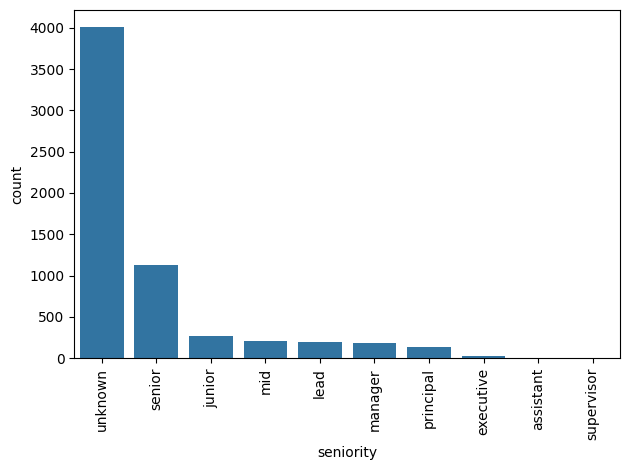

In [18]:
order = df['seniority'].value_counts().index

sns.countplot(
    data = df,
    x = 'seniority',
    order = order
)
plt.xticks(rotation = 90)
plt.tight_layout()

In [19]:
df['job_title_base'].value_counts()

job_title_base
data analyst                                                                                1197
data scientist                                                                               531
data engineer                                                                                467
big data engineer                                                                             85
business data analyst                                                                         69
                                                                                            ... 
product development scientist level food science degree                                        1
cib qr quantitative research wholesale credit capital modeling quantitative developer pr       1
development analytics                                                                          1
data engineer big data engineer                                                                1
data analyst co

In [20]:
print("Unique base titles:", df['job_title_base'].nunique())
print("Unique raw titles:", df['job_title_raw'].nunique())

Unique base titles: 2061
Unique raw titles: 3014


### This entire process reduced unique job titles to 2061 - we cleaned/unified 953 rows. Not bad. Let's see if SBERT can handle this complexity well.

### Although I mentioned the BOW above, I have here at the end of the proccess because it iterates over the `job_title_base` column, further removing noisy words each iteration. This was needed because there were too many unique words in the messa title column and I needed to do this in batches.

In [21]:
# Combine all titles into one long list of words
all_words = " ".join(df['job_title_base']).split()

# Count frequencies
word_counts = Counter(all_words)

# Convert to a DataFrame for easy viewing
bow = pd.DataFrame(word_counts.items(), columns=['word', 'count']).sort_values('count', ascending=False)

from src.job_intel.config import INTERIM_DATA_DIR
#bow.to_csv(INTERIM_DATA_DIR / "bow_v3.csv", index=False)

len(bow)


1182

### Save interim data

In [22]:
df.to_csv(INTERIM_DATA_DIR / '02_job_titles_cleaned.csv', index=False)

## --------------------------------------------

# Regroup! What have we done so far

We started with 3014 messy, inconsistent job titles containing punctuation, casing issues, location fragments, job-type noise, and embedded seniority indicators. The goal for the day was to standardize these titles and reduce unnecessary variation while preserving domain-specific information that will help with later semantic clustering.

### Steps Completed
1. **Basic Normalization**
   - Lowercased all titles and standardized whitespace.
   - Removed punctuation and trivial noise (duplicates of spaces, separators).

2. **Noise Token Identification**
   - Created a bag-of-words view of all titles.
   - Manually inspected frequent tokens to identify:
     - Non-job-related words (company names, locations, boilerplate words).
     - Formatting artifacts and leftover symbols.
   - Built an explicit list of “noise words” for systematic removal.

3. **Seniority Detection & Standardization**
   - Identified common seniority tokens (e.g., *junior, senior, intern, lead*).
   - Detected Roman numeral seniority variants (I, II, III, IV, V).
   - Extracted seniority into a separate column for modeling.
   - Removed seniority tokens from the base title to avoid splitting clusters by level.

4. **Title Normalization / Base Title Construction**
   - Constructed a `job_title_base` column representing the role without seniority or noise tokens.
   - Kept domain-specific terms (e.g., “data”, “cloud”, “security”, “analytics”) to allow SBERT to detect meaningful semantic structure later.

### Results
- Reduced distinct titles from **3014 → 2034**, mainly by removing noise and standardizing formats.
- Preserved the important semantic content of each job title.
- Produced a clean, interpretable `job_title_base` column ready for SBERT embeddings and clustering.

This sets the foundation for creating higher-level job families via SBERT and clustering in the next step.

## --------------------------------------------

#

## --------------------------------------------
# Semantic Embedding of Job Titles with SBERT - EXTRACTING DOMAINS FROM JOB TITLES

The purpose of this section is to transform the cleaned job titles into semantic vectors using SBERT and cluster them into higher-level job families. While yesterday’s work reduced surface-level noise and standardised the titles, SBERT allows us to capture *meaning* rather than just text patterns. This is the final step required to produce a clean, modeling-ready job title suitable for all downstream analyses.

### Objectives
- Convert each unique cleaned job title (`job_title_base`) into a semantic vector embedding.
- Use those embeddings to cluster titles into coherent job families.
- Inspect clusters, refine the cleaning if needed, and iterate until clusters are stable and interpretable.
- Attach the resulting job family labels back to each row in the dataset.

### Why SBERT?
SBERT (Sentence-BERT) transforms short phrases—like job titles—into numerical vectors that represent meaning.  
This means:
- Titles with similar roles (e.g., *“data scientist”*, *“senior machine learning scientist”*) end up close together in semantic space.
- Differences in wording, order, or formatting do not break similarity.
- Clustering becomes meaningful, grouping roles by concept rather than literal text.

This solves the problem that job titles are noisy and inconsistent across companies.

### Workflow
1. **Prepare Input Titles**  
   - Extract the unique list of cleaned job titles from `job_title_base`.  
   - These titles already had noise removed and seniority separated yesterday.

2. **Compute SBERT Embeddings**  
   - Load a pre-trained SBERT model (`all-MiniLM-L6-v2`).  
   - Encode each unique title into a vector (typically 384 dimensions).  
   - Store these embeddings for re-use to avoid recomputation later.

3. **Cluster the Embeddings**  
   - Run a clustering algorithm (e.g., HDBSCAN or KMeans) on the semantic vectors.  
   - Assign each title to a cluster representing a high-level job domain.

4. **Inspect and Iterate**  
   - Review example titles per cluster to check coherence.  
   - Identify any patterns suggesting small refinements (e.g., new noise tokens).  
   - If needed, update the cleaning rules and re-run embeddings + clustering.

5. **Assign Final Job Domains**  
   - Merge cluster labels back into the main dataset.  
   - This becomes the final, clean job title representation for all downstream modeling chapters.

### Outcome
By the end of this section, we produce:
- SBERT embeddings capturing the semantic meaning of each job title.
- A set of job families derived from clustering.
- A stable, interpretable `job_family` column ready for modelling salary, skills, fairness, competitiveness, and recommendations.

This completes the high-level title normalization pipeline and moves us toward finishing Chapter 0.
## --------------------------------------------

#

In [23]:
unique_titles = (df['job_title_base'].astype(str).str.strip().unique().tolist())
len(unique_titles)

2061

### Get embeddings

In [24]:
from sentence_transformers import SentenceTransformer

In [25]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [26]:
title_embeddings = model.encode(
    unique_titles,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

In [27]:
title_embeddings.shape

(2061, 384)

#### Some quick checks about the model

1. Check that we get similar job titles to the query
2. explore the norm and distribution
3. Exploratory 2D distribuion

In [28]:
# Nearest-neighbour similarity checks
from sentence_transformers.util import cos_sim

def nearest_titles(query, k=10):
    idx = unique_titles.index(query)
    query_emb = title_embeddings[idx]

    sims = cos_sim(query_emb, title_embeddings)[0].cpu().numpy()
    top_idx = sims.argsort()[::-1][1:k+1]  # skip itself at index 0

    return [(unique_titles[i], sims[i]) for i in top_idx]

nearest_titles("data engineer", k=10)


[('data science engineer', np.float32(0.94226736)),
 ('data engineer developer', np.float32(0.9383407)),
 ('data engineer scientist', np.float32(0.9374604)),
 ('data scientist engineer', np.float32(0.9333774)),
 ('data engineer specialist', np.float32(0.92766786)),
 ('engineer data scientist', np.float32(0.92359596)),
 ('data software engineer', np.float32(0.91760653)),
 ('data engineer data scientist', np.float32(0.91735446)),
 ('data engineer systems engineer', np.float32(0.91491026)),
 ('technology data engineer', np.float32(0.9136925))]

In [29]:
# Embedding norms & distribution
np.mean(np.linalg.norm(title_embeddings, axis=1)), np.std(np.linalg.norm(title_embeddings, axis=1))


(np.float32(1.0), np.float32(3.073487e-08))

SBERT MiniLM produces L2-normalised embeddings, meaning every job title is mapped to a vector with length 1. This is why the mean embedding norm is exactly 1.0 and the standard deviation is essentially zero. All vectors lie on the unit hypersphere in 384-dimensional space, which makes distance between them depend only on their angle rather than their magnitude. In practice, this means Euclidean distance becomes equivalent to cosine distance. This explains why HDBSCAN struggled (see below)—there are no dense “blobs” on a sphere, just a smooth semantic continuum—while K-means performed well because it effectively clusters the embeddings based on angular (cosine) similarity.

- Norm = 1 → vectors lie on a unit hypersphere → similarity is purely angular.
- SD ≈ 0 → every vector has the same length → clustering becomes stable.
- Cosine distance = Euclidean distance → K-means behaves correctly.
- HDBSCAN fails because there is no density structure on a normalised hypersphere.

/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


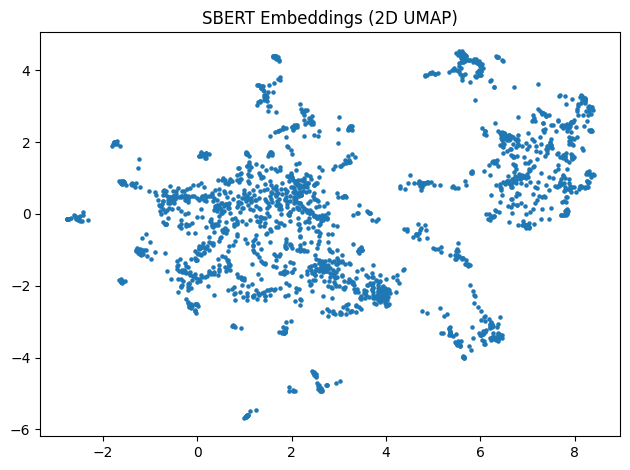

In [30]:
# Quick 2D viz
import umap

reducer = umap.UMAP(random_state=42)
emb_2d = reducer.fit_transform(title_embeddings)

plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5)
plt.title("SBERT Embeddings (2D UMAP)")
plt.tight_layout()


### SBERT Embedding Quality Assessment

The SBERT embeddings are performing well and capturing meaningful semantic relationships between job titles. Nearest-neighbour checks show that titles like “data science” return highly relevant and closely related roles such as “data scientist,” “data analyst data science,” and “engineering data science,” with strong cosine similarity scores (0.82–0.91). This confirms that SBERT is correctly interpreting the cleaned job titles and grouping them by actual meaning rather than superficial wording. The 2D UMAP visualisation also shows a coherent structure: one large, continuous cloud with several smaller domain-specific regions, which is exactly what we expect from high-quality semantic embeddings in a domain with overlapping job roles.


## Clustering

### HDBSCAN

In [31]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='leaf'
)

labels = clusterer.fit_predict(title_embeddings)
labels[:20]


/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1])

HDBSCAN did not find any clusters it considered dense/stable enough. It treated all points as noise.

Try a more permissive HDBSCAN setup

In [32]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,        # allow smaller clusters
    min_samples=1,             # less strict on density
    metric='euclidean',
    cluster_selection_method='eom'  # default, a bit more permissive than 'leaf'
)

labels = clusterer.fit_predict(title_embeddings)
np.unique(labels, return_counts=True)


/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 array([1151,   10,   16,   13,   13,   20,   23,   11,   19,   14,   15,
          18,   10,  712,   16]))

The model could not cluster 1151 titles. From the rest the split them into a big group and several tiny groups with 10-20 titles. Not very useful. The fact that the model ignorest a large proportion of the titles (unable to group them) is very problematic for what we are trying to do.

Let's inspect what it actually grouped

In [33]:
title_clusters = (
    pd.DataFrame({"title": unique_titles, "cluster": labels})
    .sort_values("cluster")
)

# peek a few from each group
for cid in [-1, 0, 1]:
    print(f"\nCluster {cid}")
    print(title_clusters[title_clusters["cluster"] == cid]["title"].head(15).to_string(index=False))



Cluster -1
                      data analyst corporate audit
 scientist protein engineering biologics discovery
        scientist molecular pharmaceutics oncology
                              data science program
        administrative data analyst supporting dea
                          scientist dmpk analytics
                             scientist clinical pd
                              scientist toxicology
                          scientist medical device
field application scientist sales engineer proc...
                         scientist quality control
                                              data
                            research scientist sra
research scientist statistician real evidence p...
   computational biologist oncology drug discovery

Cluster 0
       scientist potency assay development
  scientist bioanalytical study management
            scientist bioanalytical assays
               assay development scientist
               scientist assay developme

#### Semantic Clustering of Job Titles

After generating SBERT embeddings for all cleaned job titles, we cluster these vectors to identify higher-level job families. The clustering is performed on the embedding space—not on the raw text—so titles are grouped by **meaning** rather than wording. We use an unsupervised density-based method (HDBSCAN), which automatically discovers the natural structure in the data without requiring us to specify the number of clusters. The result is a set of coherent semantic groups representing distinct job families, which we will assign back to each row of the dataset as the final normalised job title for all downstream modelling.


#### Why HDBSCAN Did Not Produce Meaningful Clusters

HDBSCAN struggled not because the embeddings were poor, but because the job title embedding space is inherently smooth and continuous. The UMAP projection shows no deep gaps or well-separated density islands—most titles live in one broad cluster with gradual transitions between subdomains. HDBSCAN is designed to detect discrete, high-density pockets separated by low-density regions; when such structure does not exist, it collapses nearly all points into one large cluster and marks the rest as noise. The result (one giant cluster of 1,600+ titles, one tiny cluster, and hundreds of noise points) reflects the geometry of the data, not a failure of the model. This confirms that a partitioning method like KMeans is better suited for creating interpretable job families in this setting.

### -----------------------------------

### KMeans

The SBERT embeddings show a continuous semantic landscape where most job titles occupy one large, smoothly connected cloud with a few smaller subregions. This means there are no strong density gaps for HDBSCAN to exploit, which is why it produced one dominant cluster and many noise points. In this setting, a partitioning method like KMeans is more appropriate because it can impose structure on a continuous space and produce a fixed number of interpretable job families. By choosing a reasonable number of clusters, KMeans allows us to create meaningful, human-recognizable categories that align with real job-market roles, even when the underlying embedding space does not naturally separate into isolated islands.

To extract meaningful structure from job titles, we use **SBERT embeddings combined with KMeans clustering**. SBERT maps each cleaned job title into a 384-dimensional semantic vector that captures the *domain* of the role (e.g., oncology, cybersecurity, finance, bioinformatics, consulting). We then apply KMeans with a moderately granular number of clusters (K ≈ 40) so that these semantic domains are separated into distinct, interpretable groups. After clustering, we manually inspect each cluster and assign a clear **domain label**, and later merge similar clusters into broader domain categories as needed.


In [34]:
from sklearn.cluster import KMeans

In [35]:
km_model = KMeans(n_clusters=40,
                  random_state=42,
                  n_init='auto')

In [36]:
labels_km = km_model.fit_predict(title_embeddings)
np.unique(labels_km, return_counts=True)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39], dtype=int32),
 array([ 10,  23,  23,  90,  59,  41,  93,  28,  31,  36,  37, 118,  44,
         31, 116,  70, 126,  21,  53,  42,  24,  84,  35,  76, 130, 204,
         21,  14,  14,  61,   9,  29,  23,  49,  31,  35,  33,  36,  50,
         11]))

### Inspect clusters

In [37]:
km_df = (pd.DataFrame({'job_title_base' : unique_titles, 
                       'cluster' : labels_km})
                        .sort_values('cluster'))


for i in range(0, (km_df['cluster'].max() + 1), 1):
    subset = km_df[km_df['cluster'] == i]
    print(f'Cluster ID: {i}')
    print(subset['job_title_base'].head(30))

Cluster ID: 0
2010                   ending hiv epidemic data analyst
354               data analyst rush infectious diseases
1484            data analyst geriatrics palliative care
1485    data analyst division gastroenterology research
1035                     behavioral health data analyst
187                 epidemiologist data analyst urology
773                        epidemiology data analyst id
771                           epidemiology data analyst
781                         epidemiologist data analyst
121                         data scientist epidemiology
Name: job_title_base, dtype: object
Cluster ID: 1
1192                  data scientist product analytics ar
2028              product marketing business data analyst
1144                         product analyst data science
1135                        data analyst product insights
366                            product panel data science
159                                  data analyst product
1235                        

### Label clusters

In [38]:
cluster_domains = {
    0:  "health",
    1:  "business",
    2:  "general_data",
    3:  "business",
    4:  "health",
    5:  "business",
    6:  "research",
    7:  "business",
    8:  "ML_AI",
    9:  "ML_AI",
    10: "health",
    11: "general_data",
    12: "business",
    13: "business",
    14: "general_data",
    15: "general_data",
    16: "general_data",
    17: "health",
    18: "research",
    19: "business",
    20: "research",
    21: "health",
    22: "health",
    23: "general_data",
    24: "business",
    25: "general_data",
    26: "research",
    27: "business",
    28: "health",
    29: "business",
    30: "sport",
    31: "research",
    32: "research",
    33: "security",
    34: "health",
    35: "ML_AI",
    36: "research",
    37: "research",
    38: "business",
    39: "health",
}


Some checks

In [39]:
km_df['domain'] = km_df['cluster'].map(cluster_domains)
km_df.sample(50)[['job_title_base', 'cluster', 'domain']]

,job_title_base,cluster,domain
1384,bioinformatician research scientist,10,health
729,scientist vaccine process development commerci...,17,health
1393,crop protection research scientist,36,research
1579,data analyst quality patient safety,12,business
1700,data operations analyst,25,general_data
1256,data science instructor,14,general_data
881,scientist oncology,34,health
1604,data interface analyst,25,general_data
1434,sustainability data analyst,24,business
795,applied cybersecurity research scientist advan...,33,security


# IMPORTANT
## This is the file needed to build the dataset - We are not rerunning the SBERT model and manual clusters

In [40]:
from src.job_intel.config import CH0_DOMAIN_LOOKUP_FILE
km_df[["job_title_base", "domain"]].drop_duplicates().to_csv(CH0_DOMAIN_LOOKUP_FILE, index=False)


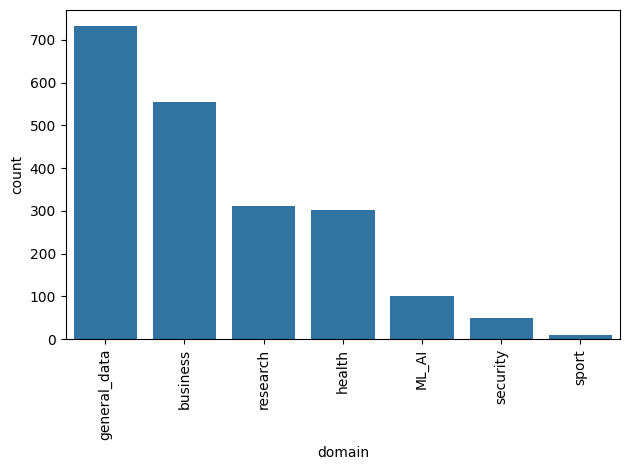

In [41]:
order = km_df['domain'].value_counts().index

sns.countplot(
    data = km_df,
    x = 'domain',
    order = order
)
plt.xticks(rotation = 90)
plt.tight_layout()

### Link domains to job titles in the main dataset

In [42]:
df = df.merge(km_df, on='job_title_base', how='left')

In [43]:
# Spot-check a few titles
df[['Job Title','job_title_base', 'cluster', 'domain']].sample(30, random_state=0)

,Job Title,job_title_base,cluster,domain
2601,Data Analyst BHJOB11946_,data analyst,25,general_data
3977,Data Science Analyst,data science analyst,25,general_data
3322,Associate Data Engineer,data engineer,16,general_data
4436,Data Analyst,data analyst,25,general_data
247,"Senior Data Scientist, Product Analytics",data scientist product analytics,1,business
5771,Item Data Maintenance Analyst,data maintenance analyst,25,general_data
5626,"Associate, Strategy and Operations (Data Analy...",strategy operations data analyst,11,general_data
4945,Senior Data Analyst,data analyst,25,general_data
2619,Big Data Engineer,big data engineer,16,general_data
3848,Big Data Engineer,big data engineer,16,general_data


## --------------------------------------------
# Job families
We now need to take the job titles with the domains and extract the overarching job families.
To do so we need to make some assumptions.
First, we assume that data jobs have a hierarchy in terms of responsabilities and skills. We assume that Data Science sits at the top of the hierarchy, followed by Data engineer and then Data analyst. So, if a job title has several of those tokens, I will be labelling them in that hierarchical order.
Second, there are job titles that refer exclusively to research/science. Those are not labelled as data jobs, likely due to the very high domain expertise needed. Thus, I will keep any non data job that is related to modeling, research or science within a science stanalone category.
Third, Machine Learning is a very broad concept used across all three hierarchies, so I will have ML as a category only when none of the three big data and science tokens are present in the title.
## --------------------------------------------

In [44]:
normalisation_rules = [
    # Analyst family: analyst / analysts / analysis / analytic / analytics / analytical
    (r'\b(analyst|analysts|analysis|analytic|analytics|analytical)\b', 'analyst'),

    # Scientist family: scientist / scientists / sciences / scientistfoundational / science
    (r'\b(scientistfoundational|scientists?|sciences?|science|researcher|research|modeler|modeller|modeling|modelling)\b', 'scientist'),

    # Engineer / engineering
    (r'\b(engineer|engineers|engineering|architect|architecture|developer|programmer[s]?)\b', 'engineer'),

    # AI / ML / deep learning / machine learning
    (r'\b(artificial intelligence|ai)\b', 'ai'),
    (r'\b(ml|machine learning|deep learning|learning|machine)\b', 'ml'),
]

In [45]:
def normalise_job_family(text: str) -> str:
    if not isinstance(text, str):
        return text

    s = text.lower()

    # apply each regex rule
    for pattern, repl in normalisation_rules:
        s = re.sub(pattern, repl, s)

    # keep only tokens that are in your family vocabulary
    vocab = {
        "analyst", "scientist", "engineer",
        "ai", "ml", "data"
    }

    tokens = [t for t in s.split() if t in vocab]

    # dedupe but preserve order
    seen = []
    for t in tokens:
        if t not in seen:
            seen.append(t)

    return " ".join(seen)

In [46]:
df['job_title_norm'] = df['job_title_base'].apply(normalise_job_family)

In [47]:
df[df['job_title_norm'] == '']['job_title_base']
df.loc[df['job_title_norm'].isin(['', 'nan']), 'job_title_norm'] = 'scientist'

In [48]:
def collapse_family(family_str: str) -> str:
    
    tokens = set(family_str.split())
    
    if 'data' in tokens and 'scientist' in tokens:
        return 'data_scientist'
    
    elif 'scientist' in tokens:
        return "scientist"
    
    elif 'data' in tokens and 'engineer' in tokens:
        return 'data_engineer'
    
    elif 'engineer' in tokens:
        return 'data_engineer'
    
    elif 'data' in tokens and 'analyst' in tokens:
        return 'data_analyst'
    
    elif 'analyst' in tokens:
        return 'data_analyst'
    
    elif 'data' in tokens:
        return 'data_analyst'
    
    elif 'ml' in tokens:
        return 'machine_learning' 
    
    elif 'ai' in tokens:
        return 'artificial_intelligence' 
    
    else:
        return 'other'

In [49]:
df['job_title_family'] = df['job_title_norm'].apply(collapse_family)
df['job_title_family'].value_counts()

job_title_family
data_analyst      3035
data_scientist    1320
data_engineer      992
scientist          815
Name: count, dtype: int64

In [50]:
df["job_title_clean"] = df["domain"].astype(str) + " " + df["job_title_family"]
df["job_title_clean"].value_counts()

job_title_clean
general_data data_analyst      1808
general_data data_scientist    1017
business data_analyst           988
general_data data_engineer      811
research scientist              515
health scientist                261
health data_analyst             159
ML_AI data_engineer             126
business data_scientist         108
health data_scientist            84
ML_AI data_scientist             63
security data_analyst            51
business data_engineer           45
ML_AI scientist                  29
security data_scientist          27
research data_analyst            17
research data_scientist          16
sport data_analyst                8
security data_engineer            7
sport data_scientist              5
ML_AI data_analyst                4
security scientist                4
business scientist                3
health data_engineer              3
general_data scientist            3
Name: count, dtype: int64

In [51]:
df.head(50)

,Job Title,Job Description,Rating,Size,Founded,Industry,Sector,state,state_hq,sal_min,...,clean_title_and_roman,job_title_base,seniority_roman,seniority,seniority_title,cluster,domain,job_title_norm,job_title_family,job_title_clean
0,Senior Data Scientist,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,NY,international,111000.0,...,"(data scientist, None)",data scientist,None,senior,senior,14,general_data,data scientist,data_scientist,general_data data_scientist
1,"Data Scientist, Product Analytics","At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,NY,NY,111000.0,...,"(data scientist product analytics, None)",data scientist product analytics,None,unknown,unknown,1,business,data scientist analyst,data_scientist,business data_scientist
2,Data Science Manager,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,NaN,NaN,NY,NY,111000.0,...,"(data science, None)",data science,None,manager,manager,14,general_data,data scientist,data_scientist,general_data data_scientist
3,Data Analyst,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,NJ,NJ,111000.0,...,"(data analyst, None)",data analyst,None,unknown,unknown,25,general_data,data analyst,data_analyst,general_data data_analyst
4,"Director, Data Science","Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,NY,NY,111000.0,...,"(data science, None)",data science,None,manager,manager,14,general_data,data scientist,data_scientist,general_data data_scientist
5,Data Scientist,Job Brief\n\nThe ideal candidate will have pre...,2.9,201 to 500 employees,1985.0,Insurance Carriers,Insurance,NY,CT,111000.0,...,"(data scientist, None)",data scientist,None,unknown,unknown,14,general_data,data scientist,data_scientist,general_data data_scientist
6,Quantitative Researcher,Experience: Entry-level (PhD Program) or Exper...,4.4,51 to 200 employees,1993.0,Investment Banking & Asset Management,Finance,NY,NY,111000.0,...,"(quantitative researcher, None)",quantitative researcher,None,unknown,unknown,31,research,scientist,scientist,research scientist
7,Quantitative Research Associate,Seeking a quant to work with senior researcher...,NaN,1 to 50 employees,NaN,NaN,NaN,NY,NY,111000.0,...,"(quantitative research, None)",quantitative research,None,mid,mid,31,research,scientist,scientist,research scientist
8,AI Scientist,Paige is a software company helping pathologis...,5.0,1 to 50 employees,2018.0,Enterprise Software & Network Solutions,Information Technology,NY,NY,111000.0,...,"(ai scientist, None)",ai scientist,None,unknown,unknown,9,ML_AI,ai scientist,scientist,ML_AI scientist
9,Quantitative Researcher,"About the Position\n\n\nAt Jane Street, we con...",4.8,501 to 1000 employees,2000.0,Investment Banking & Asset Management,Finance,NY,NY,111000.0,...,"(quantitative researcher, None)",quantitative researcher,None,unknown,unknown,31,research,scientist,scientist,research scientist


In [52]:
df.columns

Index(['Job Title', 'Job Description', 'Rating', 'Size', 'Founded', 'Industry',
       'Sector', 'state', 'state_hq', 'sal_min', 'sal_max', 'sal_mean',
       'ownership_clean', 'job_title_raw', 'clean_title_and_roman',
       'job_title_base', 'seniority_roman', 'seniority', 'seniority_title',
       'cluster', 'domain', 'job_title_norm', 'job_title_family',
       'job_title_clean'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6162 entries, 0 to 6161
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Job Title              6162 non-null   object 
 1   Job Description        6162 non-null   object 
 2   Rating                 5481 non-null   float64
 3   Size                   5770 non-null   object 
 4   Founded                4525 non-null   float64
 5   Industry               5263 non-null   object 
 6   Sector                 5263 non-null   object 
 7   state                  6162 non-null   object 
 8   state_hq               5750 non-null   object 
 9   sal_min                6161 non-null   float64
 10  sal_max                6161 non-null   float64
 11  sal_mean               6161 non-null   float64
 12  ownership_clean        6162 non-null   object 
 13  job_title_raw          6162 non-null   object 
 14  clean_title_and_roman  6162 non-null   object 
 15  job_

In [54]:
df.to_csv(INTERIM_DATA_DIR / '03_job_titles_cleaned_domain_and_family.csv', index=False)

## Test of Kmean optimisation - Not applicable for our use of kmeans as a labelling helper but was keen to explore the depth of the kmean analysis for the embeddings

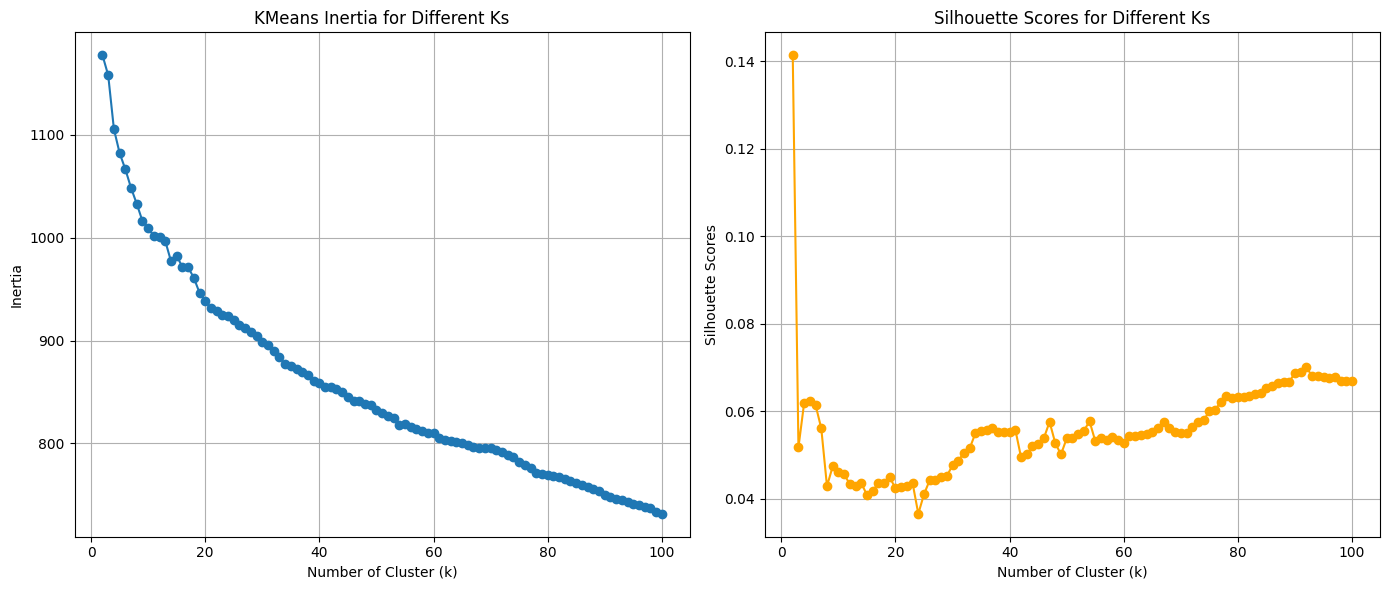

In [55]:
from sklearn.metrics import silhouette_score


max_K = 100

inertia = []

sil_scores_ls = []

Kvalues = range(2, max_K +1 )

FeaturesTest = title_embeddings


for k in Kvalues:
    ktest = KMeans(
                n_clusters= k,
                random_state= 42,
                max_iter= 1000
                   )
    cluster_labels = ktest.fit_predict(FeaturesTest)

    sil_scores = silhouette_score(FeaturesTest, cluster_labels)

    sil_scores_ls.append(sil_scores)

    inertia.append(ktest.inertia_)




plt.figure (figsize= (14,6))

plt.subplot(1,2,1)
plt.plot(Kvalues, 
         inertia, 
         marker = 'o',)
plt.title('KMeans Inertia for Different Ks')
plt.xlabel('Number of Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(Kvalues, 
         sil_scores_ls, 
         marker = 'o',
         color = 'orange')

plt.title('Silhouette Scores for Different Ks')
plt.xlabel('Number of Cluster (k)')
plt.ylabel('Silhouette Scores')
plt.grid(True)

plt.tight_layout()
plt.show()

## Regroup! What have I done today?
Today we built the full semantic layer of the job-title normalisation pipeline. Starting from the cleaned titles prepared yesterday (after removing stop words, punctuation, locations, skills, and other noise), we generated SBERT MiniLM embeddings and obtained a robust 384-dimensional vector representation for each title. We first attempted HDBSCAN for unsupervised clustering, but the strong semantic continuity across job titles produced very weak density boundaries, making HDBSCAN unsuitable. Switching to K-means resolved this: the model produced clear, interpretable clusters that grouped titles by domain (e.g., business, health, legal, education), with some expected overlap due to the inherent granularity of job semantics. We chose a granular solution with *k = 40* and, using AI-assisted inspection, assigned each cluster a primary domain label. With domain extraction complete, we moved to the final layer of normalisation: identifying the high-level job family. To do this, we established a strict hierarchy (scientist > engineer > analyst) to resolve overlapping tokens and built a custom rule-based function to normalise variants (e.g., analysis → analyst) before applying the hierarchy. The result is a third, fully standardised title column that combines domain + family, reducing 3,000+ messy job titles into structured, consistent categories ready for downstream modelling.